# EDA for HDAC8 inhibitor datasets (revision)

Exploratory analysis of the ChEMBL-derived training  and test  sets.

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from rdkit import Chem
from rdkit.Chem import Descriptors, PandasTools
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

SEED = 42
FP_RADIUS = 2
FP_SIZE = 2048

BASE_DIR = Path('.').resolve()
if (BASE_DIR / 'datasets' / 'HDAC8_train.sdf').exists():
    DATA_DIR = BASE_DIR / 'datasets'
elif (BASE_DIR.parent / 'datasets' / 'HDAC8_train.sdf').exists():
    DATA_DIR = BASE_DIR.parent / 'datasets'
else:
    DATA_DIR = BASE_DIR

TRAIN_SDF = DATA_DIR / 'HDAC8_train.sdf'
TEST_SDF = DATA_DIR / 'HDAC8_test.sdf'
OUTPUT_DIR = BASE_DIR / 'eda_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

TRAIN_SDF, TEST_SDF


(WindowsPath('C:/Users/ovtti/Jupyter Notebooks/HDAC8/REVISION/datasets/HDAC8_train.sdf'),
 WindowsPath('C:/Users/ovtti/Jupyter Notebooks/HDAC8/REVISION/datasets/HDAC8_test.sdf'))

In [8]:
def load_dataset(sdf_path: Path) -> pd.DataFrame:
    df = PandasTools.LoadSDF(
        str(sdf_path),
        smilesName='SMILES',
        molColName='Structure',
        includeFingerprints=False,
    )
    df['pchembl_value_mean'] = df['pchembl_value_mean'].astype(float)
    return df


def compute_descriptors(smiles_series: pd.Series) -> pd.DataFrame:
    rows = []
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append({c: np.nan for c in [
                'LogP', 'MW', 'NumHAcceptors', 'NumHDonors', 'NumRotatableBonds', 'TPSA'
            ]})
            continue
        rows.append({
            'LogP': Descriptors.MolLogP(mol),
            'MW': Descriptors.MolWt(mol),
            'NumHAcceptors': Descriptors.NumHAcceptors(mol),
            'NumHDonors': Descriptors.NumHDonors(mol),
            'NumRotatableBonds': Descriptors.NumRotatableBonds(mol),
            'TPSA': Descriptors.TPSA(mol),
        })
    return pd.DataFrame(rows)


def lipinski(row) -> bool:
    return (
        row['MW'] <= 500
        and row['LogP'] <= 5
        and row['NumHDonors'] <= 5
        and row['NumHAcceptors'] <= 10
    )


def veber(row) -> bool:
    return row['TPSA'] <= 140 and row['NumRotatableBonds'] <= 10


def add_druglikeness_flags(desc: pd.DataFrame) -> pd.DataFrame:
    out = desc.copy()
    out['Lipinski'] = out.apply(lipinski, axis=1)
    out['Veber'] = out.apply(veber, axis=1)
    out['Lipinski + Veber'] = out['Lipinski'] & out['Veber']
    return out


def compliance_percentages(desc_flagged: pd.DataFrame, label: str) -> pd.Series:
    n = len(desc_flagged)
    return pd.Series({
        'Subset': label,
        'N': n,
        'Lipinski (%)': round(100 * desc_flagged['Lipinski'].mean(), 1),
        'Veber (%)': round(100 * desc_flagged['Veber'].mean(), 1),
        'Lipinski + Veber (%)': round(100 * desc_flagged['Lipinski + Veber'].mean(), 1),
    })


def fingerprints_from_smiles(smiles_series: pd.Series, generator) -> np.ndarray:
    fps = []
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(smi)
        fps.append(generator.GetFingerprintAsNumPy(mol) if mol else np.zeros(FP_SIZE, dtype=np.uint8))
    return np.vstack(fps).astype(bool)


def activity_summary(df: pd.DataFrame, label: str) -> pd.Series:
    y = df['pchembl_value_mean']
    return pd.Series({
        'Subset': label,
        'N': len(y),
        'Min pIC50': round(y.min(), 2),
        'Max pIC50': round(y.max(), 2),
        'Span (log units)': round(y.max() - y.min(), 2),
    })


In [9]:
df_tr = load_dataset(TRAIN_SDF)
df_ts = load_dataset(TEST_SDF)

desc_tr = add_druglikeness_flags(compute_descriptors(df_tr['SMILES']))
desc_ts = add_druglikeness_flags(compute_descriptors(df_ts['SMILES']))

print(f'Training compounds: {len(df_tr)}')
print(f'Test compounds: {len(df_ts)}')


Training compounds: 2092
Test compounds: 524


## Lipinski and Veber compliance (compound-level percentages)

In [10]:
compliance_table = pd.DataFrame([
    compliance_percentages(desc_tr, 'Training'),
    compliance_percentages(desc_ts, 'Test'),
]).set_index('Subset')

compliance_table


,N,Lipinski (%),Veber (%),Lipinski + Veber (%)
Subset,,,,
Training,2092,78.8,82.3,73.7
Test,524,82.6,83.8,75.6


## Figure 2. pIC50 distribution (training vs. test)

Overlay histogram of experimental pIC50 values.


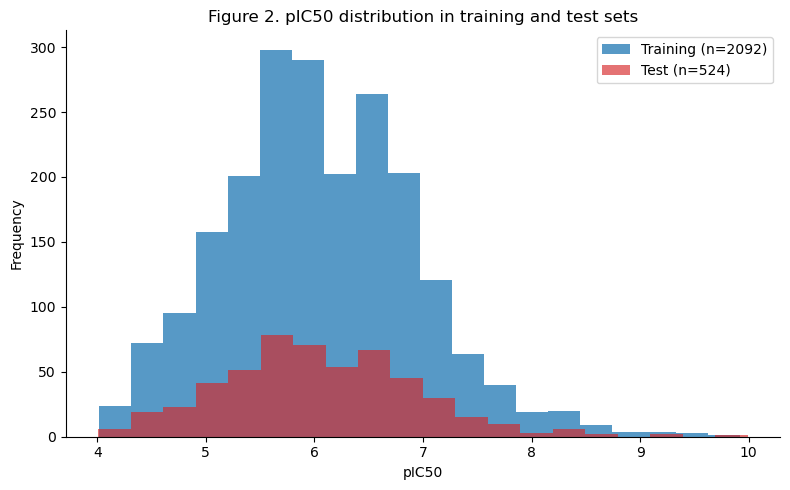

,N,Min pIC50,Max pIC50,Span (log units)
Subset,,,,
Training,2092,4.02,9.92,5.90
Test,524,4.01,9.99,5.98


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_tr['pchembl_value_mean'], bins=20, alpha=0.75, label=f'Training (n={len(df_tr)})')
ax.hist(df_ts['pchembl_value_mean'], bins=20, alpha=0.65, color='tab:red', label=f'Test (n={len(df_ts)})')
ax.set_xlabel('pIC50')
ax.set_ylabel('Frequency')
ax.set_title('Figure 2. pIC50 distribution in training and test sets')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure2_pic50_distribution.png', dpi=300)
plt.show()

activity_table = pd.DataFrame([
    activity_summary(df_tr, 'Training'),
    activity_summary(df_ts, 'Test'),
]).set_index('Subset')
activity_table


## Figures 3–4. Distribution of physicochemical descriptors (training and test sets)

Box plots show the spread of selected descriptors in both subsets. Rule compliance is reported separately as compound-level percentages above.


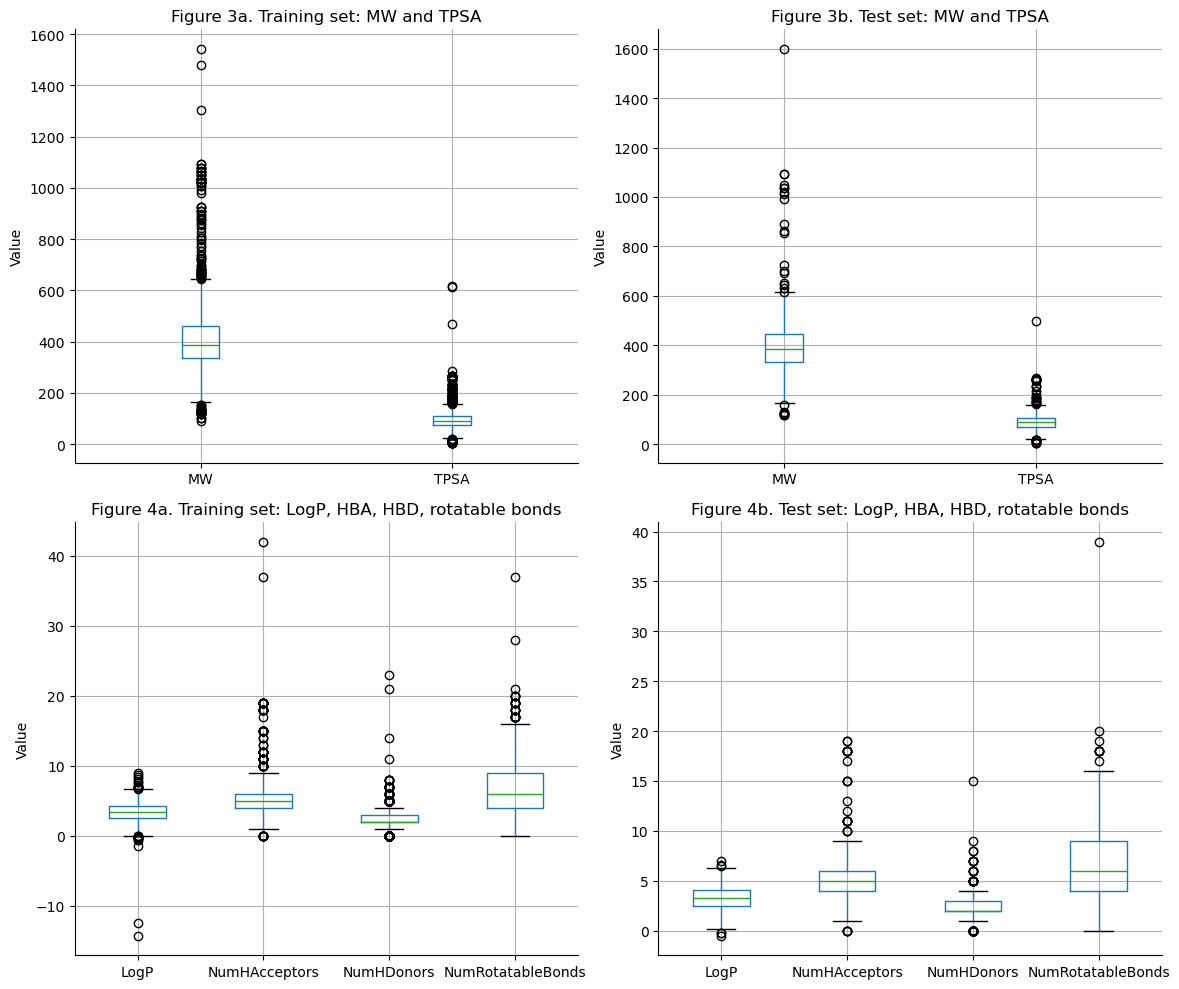

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

desc_tr.boxplot(column=['MW', 'TPSA'], ax=axes[0, 0], grid=True)
axes[0, 0].set_title('Figure 3a. Training set: MW and TPSA')
axes[0, 0].set_ylabel('Value')

desc_ts.boxplot(column=['MW', 'TPSA'], ax=axes[0, 1], grid=True)
axes[0, 1].set_title('Figure 3b. Test set: MW and TPSA')
axes[0, 1].set_ylabel('Value')

desc_tr.boxplot(column=['LogP', 'NumHAcceptors', 'NumHDonors', 'NumRotatableBonds'], ax=axes[1, 0], grid=True)
axes[1, 0].set_title('Figure 4a. Training set: LogP, HBA, HBD, rotatable bonds')
axes[1, 0].set_ylabel('Value')

desc_ts.boxplot(column=['LogP', 'NumHAcceptors', 'NumHDonors', 'NumRotatableBonds'], ax=axes[1, 1], grid=True)
axes[1, 1].set_title('Figure 4b. Test set: LogP, HBA, HBD, rotatable bonds')
axes[1, 1].set_ylabel('Value')

for ax in axes.flat:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures3_4_train_test_boxplots.png', dpi=300)
plt.show()
